In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from interpret.glassbox import ExplainableBoostingClassifier
from pygam import LogisticGAM
import pymc as pm
import pytensor.tensor as pt

In [3]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel().astype(float).astype(int)
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel().astype(float).astype(int)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("Number of original features:", X_train.shape[1])

X_train shape: (759384, 23)
y_train shape: (759384,)
Number of original features: 23


In [ ]:

def load_level2_row(csv_path):
    df = pd.read_csv(csv_path)

    level2 = df[
        df["Search Level"]
        .astype(str)
        .str.strip()
        .str.lower()
        == "level 2"
    ]

    if level2.empty:
        raise ValueError(f"No Level 2 row found in: {csv_path}")

    if len(level2) > 1:
        raise ValueError(f"More than one Level 2 row found in: {csv_path}")

    return level2.iloc[0]


lr_level2 = load_level2_row("../results/lr_best_parameters.csv")
blr_level2 = load_level2_row("../results/blr_best_parameters.csv")
ebm_level2 = load_level2_row("../results/ebm_best_parameters.csv")
gam_level2 = load_level2_row("../results/gam_best_parameters.csv")

print("LR Level 2 parameters:")
print(lr_level2)

print("\nBLR Level 2 parameters:")
print(blr_level2)

print("\nEBM Level 2 parameters:")
print(ebm_level2)

print("\nGAM Level 2 parameters:")
print(gam_level2)


LR Level 2 parameters:
Search Level           Level 2
Best C                     0.2
Best Penalty                l1
Best Solver          liblinear
Best Mean ROC-AUC     0.918351
Name: 1, dtype: object

BLR Level 2 parameters:
Search Level          Level 2
Best prior_sd             2.0
Best Mean ROC-AUC    0.912627
Best Std ROC-AUC     0.000752
Name: 1, dtype: object

EBM Level 2 parameters:
Search Level                 Level 2
interactions                    1.5x
learning_rate                   0.04
max_leaves                         3
smoothing_rounds                  25
Best Mean CV ROC-AUC        0.978269
Tuning Time             16572.872904
Name: 1, dtype: object

GAM Level 2 parameters:
Search Level          Level 2
Best Lambda            0.0005
Best Mean ROC-AUC    0.926332
Best Std ROC-AUC      0.00144
Name: 1, dtype: object


In [ ]:

lr_params = {
    "C": float(lr_level2["Best C"]),
    "penalty": str(lr_level2["Best Penalty"]),
    "solver": str(lr_level2["Best Solver"])
}

blr_prior_sd = float(blr_level2["Best prior_sd"])

ebm_params = {
    "interactions": (ebm_level2["interactions"]),
    "learning_rate": float(ebm_level2["learning_rate"]),
    "smoothing_rounds": int(ebm_level2["smoothing_rounds"]),
    "max_leaves": int(ebm_level2["max_leaves"])
}

gam_lambda = float(gam_level2["Best Lambda"])

print("Final LR parameters:", lr_params)
print("Final BLR prior_sd:", blr_prior_sd)
print("Final EBM parameters:", ebm_params)
print("Final GAM lambda:", gam_lambda)


Final LR parameters: {'C': 0.2, 'penalty': 'l1', 'solver': 'liblinear'}
Final BLR prior_sd: 2.0
Final EBM parameters: {'interactions': '1.5x', 'learning_rate': 0.04, 'smoothing_rounds': 25, 'max_leaves': 3}
Final GAM lambda: 0.0005


In [ ]:

pca = PCA(
    n_components=0.90,
    random_state=42
)

start_time = time.time()

X_train_pca_array = pca.fit_transform(X_train)
X_test_pca_array = pca.transform(X_test)

pca_transformation_time = time.time() - start_time

pca_columns = [
    f"PC{i + 1}"
    for i in range(pca.n_components_)
]

X_train_pca = pd.DataFrame(
    X_train_pca_array,
    columns=pca_columns
)

X_test_pca = pd.DataFrame(
    X_test_pca_array,
    columns=pca_columns
)

print("Original number of features:", X_train.shape[1])
print("Number of PCA components:", pca.n_components_)
print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum(), 6)
)
print(
    "PCA transformation time:",
    round(pca_transformation_time, 2),
    "seconds"
)
print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)


Original number of features: 23
Number of PCA components: 9
Total explained variance: 0.917263
PCA transformation time: 0.41 seconds
X_train_pca shape: (759384, 9)
X_test_pca shape: (118799, 9)


In [ ]:

joblib.dump(
    pca,
    "../models/pca_transformer.pkl"
)

pca_summary_df = pd.DataFrame({
    "Item": [
        "Original Number of Features",
        "Number of PCA Components",
        "Total Explained Variance",
        "PCA Transformation Time"
    ],
    "Value": [
        X_train.shape[1],
        pca.n_components_,
        pca.explained_variance_ratio_.sum(),
        pca_transformation_time
    ]
})

pca_summary_df.to_csv(
    "../results/pca_summary.csv",
    index=False
)

pca_variance_df = pd.DataFrame({
    "Principal Component": pca_columns,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(
        pca.explained_variance_ratio_
    )
})

pca_variance_df.to_csv(
    "../results/pca_explained_variance.csv",
    index=False
)

print("PCA transformer and results saved successfully.")
pca_summary_df


PCA transformer and results saved successfully.


,Item,Value
0,Original Number of Features,23.000000
1,Number of PCA Components,9.000000
2,Total Explained Variance,0.917263
3,PCA Transformation Time,0.413441


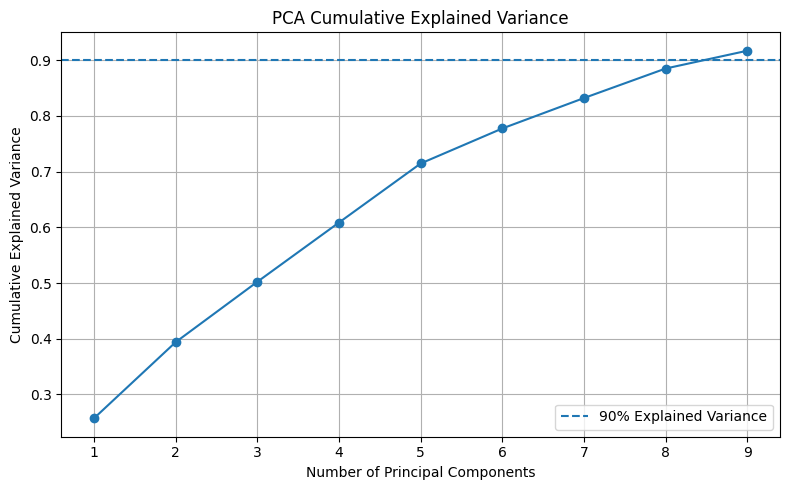

In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, pca.n_components_ + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Explained Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
def evaluate_binary_model(
    model_name,
    y_true,
    y_pred,
    y_prob,
    training_time,
    num_components
):
    y_true = (
        np.asarray(y_true)
        .astype(float)
        .astype(int)
        .ravel()
    )

    y_pred = (
        np.asarray(y_pred)
        .astype(float)
        .astype(int)
        .ravel()
    )

    y_prob = np.asarray(
        y_prob,
        dtype=float
    ).ravel()

    y_prob = np.clip(
        y_prob,
        1e-15,
        1 - 1e-15
    )

    return {
        "Model": model_name,
        "Number of Components": num_components,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier Score": brier_score_loss(
            y_true,
            y_prob
        ),
        "Training Time": training_time
    }


def save_vertical_results(
    result,
    model_name,
    file_name
):
    evaluation_df = pd.DataFrame({
        "Metric": [
            "Number of Components",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "Log Loss",
            "Brier Score",
            "Training Time"
        ],
        model_name: [
            result["Number of Components"],
            result["Accuracy"],
            result["Precision"],
            result["Recall"],
            result["F1 Score"],
            result["ROC-AUC"],
            result["Log Loss"],
            result["Brier Score"],
            result["Training Time"]
        ]
    })

    evaluation_df.to_csv(
        file_name,
        index=False
    )

    return evaluation_df


all_pca_results = []


In [ ]:

lr_pca_model = LogisticRegression(
    C=lr_params["C"],
    penalty=lr_params["penalty"],
    solver=lr_params["solver"],
    max_iter=3000,
    random_state=42
)

start_time = time.time()

lr_pca_model.fit(
    X_train_pca,
    y_train
)

lr_pca_time = time.time() - start_time

y_pred_lr_pca = lr_pca_model.predict(X_test_pca)

y_prob_lr_pca = lr_pca_model.predict_proba(
    X_test_pca
)[:, 1]

lr_pca_result = evaluate_binary_model(
    "LR + PCA",
    y_test,
    y_pred_lr_pca,
    y_prob_lr_pca,
    lr_pca_time,
    pca.n_components_
)

lr_pca_df = save_vertical_results(
    lr_pca_result,
    "LR + PCA",
    "../results/lr_pca_evaluation_results.csv"
)

all_pca_results.append(lr_pca_result)

joblib.dump(
    lr_pca_model,
    "../models/lr_pca_model.pkl"
)

print("LR + PCA model and results saved successfully.")

lr_pca_df


LR + PCA model and results saved successfully.


,Metric,LR + PCA
0,Number of Components,9.000000
1,Accuracy,0.728390
2,Precision,0.897699
3,Recall,0.744478
4,F1 Score,0.813940
5,ROC-AUC,0.779533
6,Log Loss,0.571163
7,Brier Score,0.190267
8,Training Time,1.075213


In [ ]:

X_train_pca_np = X_train_pca.values.astype("float32")
X_test_pca_np = X_test_pca.values.astype("float32")
y_train_np = y_train.astype("int32")

n_pca_components = X_train_pca_np.shape[1]

start_time = time.time()

with pm.Model() as blr_pca_pymc_model:
    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=blr_prior_sd
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=blr_prior_sd,
        shape=n_pca_components
    )

    logits = alpha + pt.dot(
        X_train_pca_np,
        beta
    )

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(logits)
    )

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y_train_np
    )

    approximation = pm.fit(
        n=20000,
        method="advi",
        random_seed=42,
        progressbar=False
    )

    blr_pca_trace = approximation.sample(
        draws=1000,
        random_seed=42
    )

blr_pca_time = time.time() - start_time

alpha_samples_pca = (
    blr_pca_trace.posterior["alpha"]
    .values
    .reshape(-1)
)

beta_samples_pca = (
    blr_pca_trace.posterior["beta"]
    .values
    .reshape(-1, n_pca_components)
)

alpha_mean_pca = alpha_samples_pca.mean()
beta_mean_pca = beta_samples_pca.mean(axis=0)

blr_logits_test_pca = (
    alpha_mean_pca
    + X_test_pca_np @ beta_mean_pca
)

y_prob_blr_pca = expit(
    blr_logits_test_pca
)

y_pred_blr_pca = (
    y_prob_blr_pca >= 0.5
).astype(int)

blr_pca_result = evaluate_binary_model(
    "BLR + PCA",
    y_test,
    y_pred_blr_pca,
    y_prob_blr_pca,
    blr_pca_time,
    pca.n_components_
)

blr_pca_df = save_vertical_results(
    blr_pca_result,
    "BLR + PCA",
    "../results/blr_pca_evaluation_results.csv"
)

all_pca_results.append(blr_pca_result)

blr_pca_model_data = {
    "alpha_mean": alpha_mean_pca,
    "beta_mean": beta_mean_pca,
    "alpha_samples": alpha_samples_pca,
    "beta_samples": beta_samples_pca,
    "best_prior_sd": blr_prior_sd,
    "columns": pca_columns
}

joblib.dump(
    blr_pca_model_data,
    "../models/blr_pca_model.pkl"
)

print("BLR + PCA model and results saved successfully.")

blr_pca_df


Finished [100%]: Average Loss = 4.3119e+05


BLR + PCA model and results saved successfully.


,Metric,BLR + PCA
0,Number of Components,9.000000
1,Accuracy,0.728390
2,Precision,0.897729
3,Recall,0.744446
4,F1 Score,0.813934
5,ROC-AUC,0.779548
6,Log Loss,0.571149
7,Brier Score,0.190242
8,Training Time,2981.138281


In [ ]:

ebm_pca_model = ExplainableBoostingClassifier(
    smoothing_rounds=ebm_params["smoothing_rounds"],
    learning_rate=ebm_params["learning_rate"],
    max_leaves=ebm_params["max_leaves"],
    interactions=ebm_params["interactions"],
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

ebm_pca_model.fit(
    X_train_pca,
    y_train
)

ebm_pca_time = time.time() - start_time

y_pred_ebm_pca = ebm_pca_model.predict(
    X_test_pca
)

y_prob_ebm_pca = ebm_pca_model.predict_proba(
    X_test_pca
)[:, 1]

ebm_pca_result = evaluate_binary_model(
    "EBM + PCA",
    y_test,
    y_pred_ebm_pca,
    y_prob_ebm_pca,
    ebm_pca_time,
    pca.n_components_
)

ebm_pca_df = save_vertical_results(
    ebm_pca_result,
    "EBM + PCA",
    "../results/ebm_pca_evaluation_results.csv"
)

all_pca_results.append(ebm_pca_result)

joblib.dump(
    ebm_pca_model,
    "../models/ebm_pca_model.pkl"
)

ebm_pca_importance_df = pd.DataFrame({
    "Term": ebm_pca_model.term_names_,
    "Importance": ebm_pca_model.term_importances()
}).sort_values(
    "Importance",
    ascending=False
)

ebm_pca_importance_df.to_csv(
    "../results/ebm_pca_component_importance.csv",
    index=False
)

print("EBM + PCA model and results saved successfully.")

ebm_pca_df


EBM + PCA model and results saved successfully.


,Metric,EBM + PCA
0,Number of Components,9.000000
1,Accuracy,0.840049
2,Precision,0.934533
3,Recall,0.859792
4,F1 Score,0.895606
5,ROC-AUC,0.891175
6,Log Loss,0.379531
7,Brier Score,0.117224
8,Training Time,8555.317285


In [14]:

GAM_TRAIN_SIZE = None

if (
    GAM_TRAIN_SIZE is not None
    and GAM_TRAIN_SIZE < len(X_train_pca)
):
    from sklearn.model_selection import train_test_split

    (
        X_gam_pca_train,
        _,
        y_gam_pca_train,
        _
    ) = train_test_split(
        X_train_pca,
        y_train,
        train_size=GAM_TRAIN_SIZE,
        stratify=y_train,
        random_state=42
    )
else:
    X_gam_pca_train = X_train_pca
    y_gam_pca_train = y_train

print(
    "GAM + PCA training shape:",
    X_gam_pca_train.shape
)

gam_pca_model = LogisticGAM(
    lam=gam_lambda,
    max_iter=500,
    tol=1e-4,
    verbose=False
)

start_time = time.time()

gam_pca_model.fit(
    X_gam_pca_train.values,
    y_gam_pca_train
)

gam_pca_time = time.time() - start_time

y_prob_gam_pca = gam_pca_model.predict_proba(
    X_test_pca.values
)

y_pred_gam_pca = (
    y_prob_gam_pca >= 0.5
).astype(int)

gam_pca_result = evaluate_binary_model(
    "GAM + PCA",
    y_test,
    y_pred_gam_pca,
    y_prob_gam_pca,
    gam_pca_time,
    pca.n_components_
)

gam_pca_df = save_vertical_results(
    gam_pca_result,
    "GAM + PCA",
    "../results/gam_pca_evaluation_results.csv"
)

all_pca_results.append(gam_pca_result)

joblib.dump(
    gam_pca_model,
    "../models/gam_pca_model.pkl"
)

print("GAM + PCA model and results saved successfully.")

gam_pca_df


GAM + PCA training shape: (759384, 9)
GAM + PCA model and results saved successfully.


,Metric,GAM + PCA
0,Number of Components,9.000000
1,Accuracy,0.852751
2,Precision,0.936828
3,Recall,0.874444
4,F1 Score,0.904562
5,ROC-AUC,0.898923
6,Log Loss,0.355322
7,Brier Score,0.110053
8,Training Time,384.694454


In [ ]:

completed_pca_results = []

for result_name in [
    "lr_pca_result",
    "blr_pca_result",
    "ebm_pca_result",
    "gam_pca_result"
]:
    if result_name in globals():
        completed_pca_results.append(
            globals()[result_name]
        )

if not completed_pca_results:
    raise ValueError(
        "No PCA model results are available. "
        "Run at least one model section first."
    )

pca_model_comparison_df = pd.DataFrame(
    completed_pca_results
)

metric_columns = [
    "Number of Components",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Log Loss",
    "Brier Score",
    "Training Time"
]

for column in metric_columns:
    pca_model_comparison_df[column] = pd.to_numeric(
        pca_model_comparison_df[column],
        errors="coerce"
    )

pca_model_comparison_vertical = (
    pca_model_comparison_df
    .set_index("Model")
    [metric_columns]
    .T
)

pca_model_comparison_vertical.index.name = "Metric"

pca_model_comparison_vertical.to_csv(
    "../results/pca_models_comparison.csv"
)

print("All completed PCA model results saved successfully.")

pca_model_comparison_vertical.round(6)


All completed PCA model results saved successfully.


Model,LR + PCA,BLR + PCA,EBM + PCA,GAM + PCA
Metric,,,,
Number of Components,9.000000,9.000000,9.000000,9.000000
Accuracy,0.728390,0.728390,0.840049,0.852751
Precision,0.897699,0.897729,0.934533,0.936828
Recall,0.744478,0.744446,0.859792,0.874444
F1 Score,0.813940,0.813934,0.895606,0.904562
ROC-AUC,0.779533,0.779548,0.891175,0.898923
Log Loss,0.571163,0.571149,0.379531,0.355322
Brier Score,0.190267,0.190242,0.117224,0.110053
Training Time,1.075213,2981.138281,8555.317285,384.694454


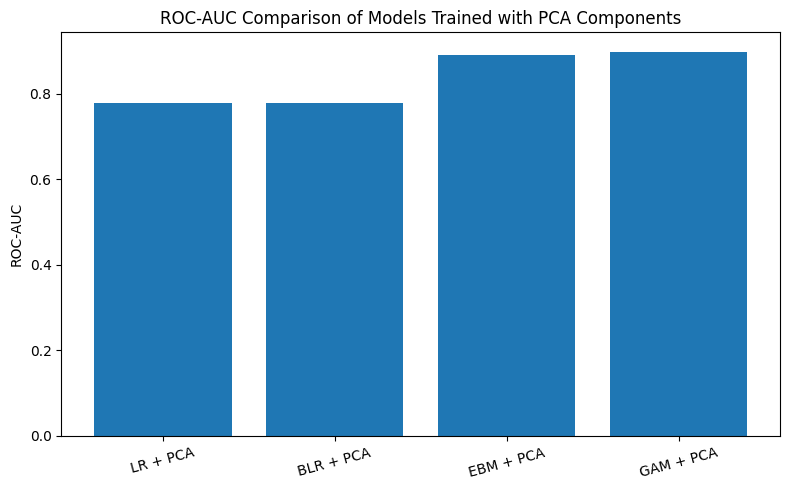

In [ ]:

plt.figure(figsize=(8, 5))

plt.bar(
    pca_model_comparison_df["Model"],
    pca_model_comparison_df["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title(
    "ROC-AUC Comparison of Models Trained with PCA Components"
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
